In [2]:
import requests
from bs4 import BeautifulSoup

url = "https://raw.githubusercontent.com/SimplifyJobs/Summer2026-Internships/dev/README.md"
response = requests.get(url)
soup = BeautifulSoup(response.text, 'lxml') 
print("Data Fetched!")

Data Fetched!


In [3]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import io

# 1. Fetch the raw content
url = "https://raw.githubusercontent.com/SimplifyJobs/Summer2026-Internships/dev/README.md"
response = requests.get(url)
full_text = response.text

# 2. FIND THE START AND END OF THE DATA SCIENCE SECTION
# We use simple string finding because it's more reliable than BeautifulSoup for large files
start_keyword = "## 🤖 Data Science, AI & Machine Learning Internship Roles"
next_section_keyword = "## " # The next header (e.g., Quant or Hardware)

start_idx = full_text.find(start_keyword)
'''
we are findinfg the index of the section we are searching for and we are using
it as a starting index to travers untill the end index or
otherwise the next section/ end of file

'''
if start_idx != -1:
    # Find where the NEXT section starts to crop the text
    #str.find(sub[, start[, end]])...(##, index )
    end_idx = full_text.find(next_section_keyword, start_idx + len(start_keyword))
    # If there is no next section, go to the end of the file
    if end_idx == -1:
        end_idx = len(full_text)
        
    # slice the text to ONLY the Data Science section
    ds_content = full_text[start_idx:end_idx]
    
    # 3. PARSE ALL TABLES IN THIS CROP
    soup = BeautifulSoup(ds_content, 'html.parser')
    tables = soup.find_all('table')
    
    all_rows = []
    for table in tables:
        rows = table.find_all('tr')[1:] # Skip header row
        for row in rows:
            cols = row.find_all('td')
            if len(cols) >= 2:
                company = cols[0].get_text(separator=" ").strip()
                role = cols[1].get_text(separator=" ").strip()
                
                # DATA MINING: Check for the Advanced Degree symbol 🎓
                is_adv = "🎓" in company or "🎓" in role
                
                all_rows.append({
                    "Company": company.replace("🎓", "").strip(),
                    "Role": role.replace("🎓", "").strip(),
                    "Is_Advanced": is_adv
                })

    # 4. DATA ANALYSIS
    df = pd.DataFrame(all_rows)
    if not df.empty:
        adv_pct = df['Is_Advanced'].mean() * 100
        print(f"✅ Successfully scanned the Data Science section.")
        print(f"📊 Total Roles Found: {len(df)}")
        print(f"🎓 Advanced Degree Required: {adv_pct:.1f}%")
        
        # Displaying the Advanced Roles
        display(df[df['Is_Advanced'] == True][['Company', 'Role']])
    else:
        print("Found the header, but no tables were found in that section.")
else:
    print("Error: Could not find the Data Science header in the full document.")

✅ Successfully scanned the Data Science section.
📊 Total Roles Found: 333
🎓 Advanced Degree Required: 29.7%


,Company,Role
6,Sandisk,Agentic AI Intern
13,X Development,PhD Resident - AI for Chemistry - Early Stage ...
22,🔥 Amazon,Economics Intern - Economic Decision Science
25,Faherty Brand,MBA Intern - AI Retail Project
29,GE Vernova,GE Vernova GenAI Intern
...,...,...
321,Kaiser Permanente,Data Reporting and Analytics Master's Intern
322,Tencent,Hunyuan Multimodal Reinforcement Learning Rese...
323,↳,Hunyuan Multimodal Reinforcement Learning Rese...
326,Juniper Square,AI Engineer Intern


Advanced Degree Requirement: 29.73%


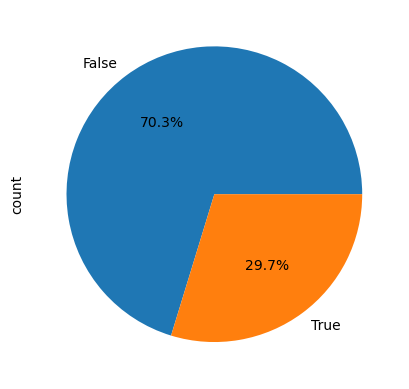

In [4]:
import matplotlib.pyplot as plt

adv_pct = df['Is_Advanced'].mean() * 100
print(f"Advanced Degree Requirement: {adv_pct:.2f}%")

df['Is_Advanced'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.show()